In [2]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

#### Set A

##### Q1 
Create ‘sales’ Data set having 5 columns namely: ID, TV, Radio, Newspaper and Sales.(random 
500 entries) Build a linear regression model by identifying independent and target variable. Split 
the variables into training and testing sets. then divide the training and testing sets into a 7:3 
ratio, respectively and print them. Build a simple linear regression model.

In [3]:
# Define/Load the dataset
sales = pd.DataFrame({
    "TV":        np.random.randint(10, 300, 500),
    "Radio":     np.random.randint(1,  50,  500),
    "Newspaper": np.random.randint(10, 100, 500),
    "Sales":     np.random.randint(10, 100, 500)
})
print("Sales Dataset:\n", sales.head())

Sales Dataset:
     TV  Radio  Newspaper  Sales
0  189     45         61     32
1   26     12         18     11
2  112      6         55     62
3  273     47         52     23
4  259     29         95     39


In [4]:
# Select features (X) and target (y)
X, y = sales[["TV", "Radio", "Newspaper"]], sales["Sales"]

In [5]:
# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [6]:
# Train the Linear Regression model
model = LinearRegression().fit(X_train, y_train)

In [7]:
# Display model parameters
print("Coefficients:", model.coef_)
print("Intercept:",    model.intercept_)

Coefficients: [-0.01510666 -0.00793682  0.06033948]
Intercept: 54.49356175560326


In [8]:
# Predict and evaluate
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 637.315921850733
R2 Score: -0.008460840771391753


##### Q2
Create ‘realestate’ Data set having 4 columns namely: ID, flat, houses and purchases (random 
500 entries). Build a linear regression model by identifying independent and target variable. 
Split the variables into training and testing sets and print them. Build a simple linear regression 
model for predicting purchases. 

In [9]:
# Create a new dataset for real estate
realestate = pd.DataFrame({
    "Flat":     np.random.randint(1, 50,  500),
    "Houses":   np.random.randint(1, 30,  500),
    "Purchase": np.random.randint(1, 100, 500)
})
print("\nReal Estate Dataset:\n", realestate.head())


Real Estate Dataset:
    Flat  Houses  Purchase
0    41      24        90
1     9      25        96
2    48      26        99
3    17      13        23
4    31       1        39


In [10]:
# Select features (X) and target (y)
X, y = realestate[["Flat", "Houses"]], realestate["Purchase"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

In [11]:
# Train the Linear Regression model
model = LinearRegression().fit(X_train, y_train)

# Display model parameters
# Coefficients indicate the change in the target variable for a one-unit change in the feature, 
# while the intercept is the expected value of the target when all features are zero.
print("RealEstate - Coefficients:", model.coef_, "| Intercept:", model.intercept_)

RealEstate - Coefficients: [ 0.21395075 -0.06084355] | Intercept: 44.03397822717625


##### Q3
Create ‘User’ Data set having 5 columns namely: User ID, Gender, Age, EstimatedSalary and 
Purchased. Build a logistic regression model that can predict whether on the given parameter 
a person will buy a car or not.

In [ ]:
# Define a new dataset for logistic regression
df = pd.DataFrame({
    "Gender":    np.random.choice(["Male", "Female"], 500),
    "Age":       np.random.randint(18, 60, 500),
    "Salary":    np.random.randint(20000, 150000, 500),
    "Purchased": np.random.choice([0, 1], 500)
})

In [ ]:
# Encode the categorical variable 'Gender' to numeric values
df["Gender"] = LabelEncoder().fit_transform(df["Gender"])
print("\nCar Purchase Dataset:\n", df.head())


Car Purchase Dataset:
    Gender  Age  Salary  Purchased
0       1   37   48227          1
1       1   35   30847          1
2       1   24  142893          0
3       1   20  103321          1
4       1   37   49851          0


In [ ]:
# Select features (X) and target (y)
X, y = df[["Gender", "Age", "Salary"]], df["Purchased"]

In [ ]:
# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Standardize the features for better performance of logistic regression
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

In [ ]:
# Train the Logistic Regression model
model = LogisticRegression(max_iter=500)
model.fit(X_train_s, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Predict and evaluate
y_pred = model.predict(X_test_s)

In [ ]:
# Accuracy is the proportion of correct predictions (both true positives and true negatives) among the total number of cases examined.
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.49333333333333335


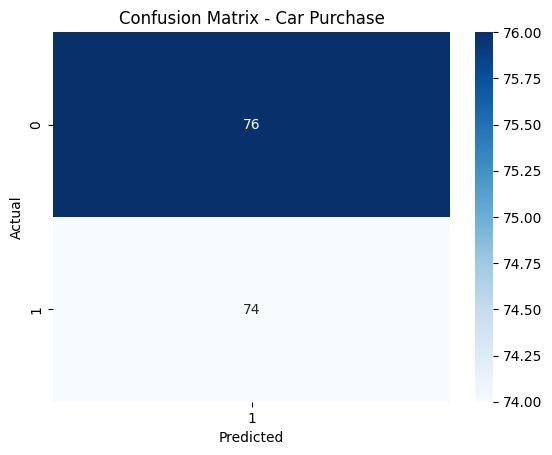

In [ ]:
# Create a confusion matrix to visualize the performance of the logistic regression model
confusion_matrix = pd.crosstab(y_test, y_pred, rownames=["Actual"], colnames=["Predicted"])
sn.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Car Purchase")
plt.show()

#### Set B

##### Q1

In [ ]:
# Load the fish dataset
df = pd.read_csv("fish_species_weight.csv")
print("\nFish Dataset:\n", df.head())


Fish Dataset:
   Species  Length  Height  Width   Weight
0    Pike   57.24   14.23   8.27  5394.59
1   Smelt    9.38    2.33   0.80    15.03
2   Perch   19.76   15.30   3.12   847.46
3   Smelt   13.83    2.76   0.89    34.59
4   Smelt   10.67    2.93   0.83    27.99


In [ ]:
# Encode the categorical variable 'Species' to numeric values
df["Species"] = LabelEncoder().fit_transform(df["Species"])

In [ ]:
# Select features (X) and target (y)
X = df[["Species", "Length", "Width"]]
y = df["Weight"]

In [ ]:
# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("Training shape:", X_train.shape, "| Testing shape:", X_test.shape)

Training shape: (105, 3) | Testing shape: (45, 3)


In [ ]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# Predict and evaluate
y_pred = model.predict(X_test)

In [ ]:
# MSE (Mean Squared Error) measures the average squared difference between the predicted and actual values, 
# while R2 Score indicates the proportion of variance in the dependent variable that is predictable from the independent variables.
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 587479.5244057133
R2 Score: 0.8859601891573923


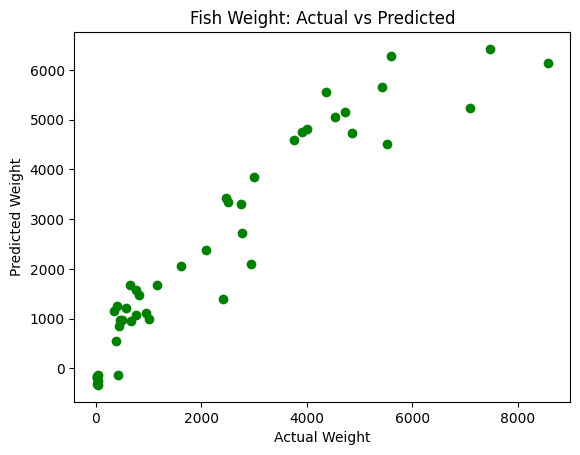

In [ ]:
# Visualize the actual vs predicted weights
plt.scatter(y_test, y_pred, color="green")
plt.xlabel("Actual Weight")
plt.ylabel("Predicted Weight")
plt.title("Fish Weight: Actual vs Predicted")
plt.show()

##### Q2

In [ ]:
# Load the iris dataset
df = pd.read_csv("iris_dataset.csv")
print("Iris Dataset:\n", df.head())
print("\nIris Dataset Description:\n", df.describe())

Iris Dataset:
    SepalLength  SepalWidth  PetalLength  PetalWidth Species
0          5.1         3.5          1.4         0.2  Setosa
1          4.9         3.0          1.4         0.2  Setosa
2          4.7         3.2          1.3         0.2  Setosa
3          4.6         3.1          1.5         0.2  Setosa
4          5.0         3.6          1.4         0.2  Setosa

Iris Dataset Description:
        SepalLength  SepalWidth  PetalLength  PetalWidth
count   150.000000  150.000000   150.000000  150.000000
mean      5.843333    3.057333     3.758000    1.199333
std       0.828066    0.435866     1.765298    0.762238
min       4.300000    2.000000     1.000000    0.100000
25%       5.100000    2.800000     1.600000    0.300000
50%       5.800000    3.000000     4.350000    1.300000
75%       6.400000    3.300000     5.100000    1.800000
max       7.900000    4.400000     6.900000    2.500000


In [ ]:
# Encode the categorical variable 'Species' to numeric values
X = df.drop("Species", axis=1)
y = LabelEncoder().fit_transform(df["Species"])

In [ ]:
# Split into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("Training shape:", X_train.shape, "| Testing shape:", X_test.shape)

Training shape: (105, 4) | Testing shape: (45, 4)


In [ ]:
# Train the Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# Predict and evaluate
y_pred = model.predict(X_test)
print("Iris Accuracy:", accuracy_score(y_test, y_pred))

Iris Accuracy: 0.9777777777777777
